In [3]:
import requests
import pandas as pd
import csv

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"

parametros = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join([
        "temperature_2m",
        "relative_humidity_2m",
        "cloud_cover",
        "wind_speed_10m",
        "shortwave_radiation"
    ])
}

print("Consultando Open-Meteo...")

resposta = requests.get(URL_METEO, params=parametros)
resposta.raise_for_status()

dados = resposta.json()

if "hourly" not in dados:
    raise ValueError("A resposta da API não contém a seção 'hourly'.")

horas = dados["hourly"]

Consultando Open-Meteo...


In [5]:
linhas = []

for i, data_hora in enumerate(horas["time"]):

    hora = int(data_hora[11:13])

    temperatura = horas["temperature_2m"][i]
    umidade = horas["relative_humidity_2m"][i]
    nuvens = horas["cloud_cover"][i]
    vento = horas["wind_speed_10m"][i]
    radiacao = horas["shortwave_radiation"][i]

    if (
        7 <= hora <= 17
        and temperatura is not None
        and umidade is not None
        and nuvens is not None
        and vento is not None
        and radiacao is not None
    ):
        linhas.append([
            data_hora,
            temperatura,
            umidade,
            nuvens,
            vento,
            hora,
            radiacao
        ])

print(f"Foram obtidos {len(linhas)} registros.")

Foram obtidos 1001 registros.


In [6]:
nome_arquivo = "meteo_regressao_orange.csv"

with open(nome_arquivo, "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)

    escritor.writerow([
        "data_hora",
        "temperatura_c",
        "umidade_pct",
        "nuvens_pct",
        "vento_kmh",
        "hora",
        "radiacao_w_m2"
    ])

    escritor.writerows(linhas)

print(f"Arquivo '{nome_arquivo}' criado com sucesso!")

Arquivo 'meteo_regressao_orange.csv' criado com sucesso!


In [7]:
print("Consultando Open-Meteo...")
print(f"Arquivo '{nome_arquivo}' criado com sucesso!")
print(f"Foram obtidos {len(linhas)} registros.")

df = pd.read_csv(nome_arquivo)

print("\nPrimeiras linhas:")
print(df.head())

print("\nInformações:")
print(df.info())

print("\nEstatísticas:")
print(df.describe())


Consultando Open-Meteo...
Arquivo 'meteo_regressao_orange.csv' criado com sucesso!
Foram obtidos 1001 registros.

Primeiras linhas:
          data_hora  temperatura_c  umidade_pct  nuvens_pct  vento_kmh  hora  \
0  2025-04-01T07:00           25.3           74         100       17.7     7   
1  2025-04-01T08:00           26.5           66         100       18.1     8   
2  2025-04-01T09:00           28.4           55          97       18.0     9   
3  2025-04-01T10:00           30.8           44          21       18.4    10   
4  2025-04-01T11:00           32.7           36          26       20.1    11   

   radiacao_w_m2  
0          116.0  
1          269.0  
2          529.0  
3          797.0  
4          880.0  

Informações:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   data_hora      1001 non-null   object 
 1   temperatura_c  1

## Análise dos dados

O conjunto de dados contém informações meteorológicas horárias obtidas pela API Open-Meteo para Petrolina (PE), no período de 1º de abril a 30 de junho de 2025.

As variáveis disponíveis são:

- **data_hora**: data e horário da observação;
- **temperatura_c**: temperatura em graus Celsius;
- **umidade_pct**: umidade relativa do ar em porcentagem;
- **nuvens_pct**: cobertura de nuvens em porcentagem;
- **vento_kmh**: velocidade do vento em km/h;
- **hora**: hora local da observação;
- **radiacao_w_m2**: radiação solar horizontal em W/m².

O objetivo da regressão é estimar a radiação solar (**radiacao_w_m2**) utilizando as demais variáveis meteorológicas e a hora local como entradas.

In [8]:
print("Valores ausentes por coluna:")
print(df.isnull().sum())

print("\nQuantidade de registros:")
print(len(df))


Valores ausentes por coluna:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64

Quantidade de registros:
1001


## Visualização dos dados

O gráfico abaixo apresenta a variação da radiação solar ao longo dos registros coletados. Essa visualização permite observar como a radiação varia durante o período analisado.

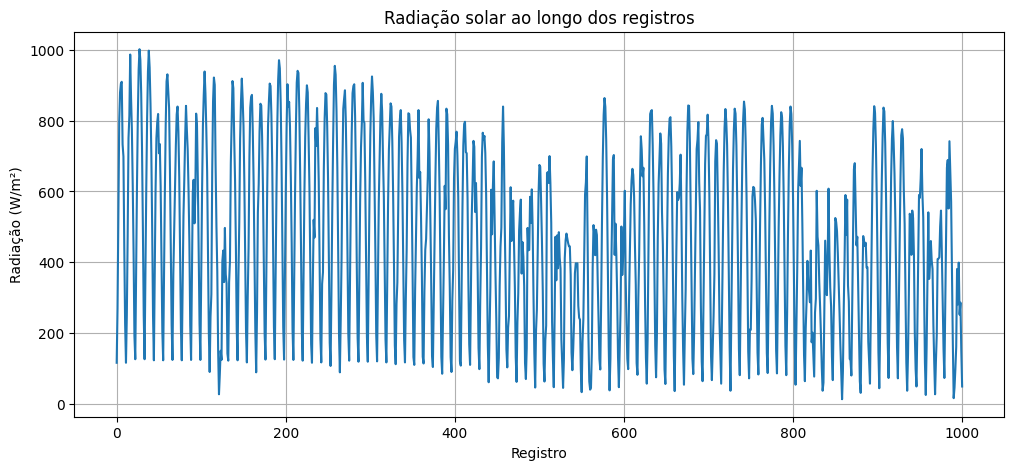

In [9]:
plt.figure(figsize=(12, 5))

plt.plot(df["radiacao_w_m2"])

plt.title("Radiação solar ao longo dos registros")
plt.xlabel("Registro")
plt.ylabel("Radiação (W/m²)")
plt.grid(True)

plt.show()

## Definição das variáveis

A variável alvo (**y**) será **radiacao_w_m2**, pois o objetivo é estimar a radiação solar.

As variáveis de entrada (**X**) serão:

- **temperatura_c**
- **umidade_pct**
- **nuvens_pct**
- **vento_kmh**
- **hora**

A coluna **data_hora** não será utilizada diretamente como entrada do modelo.

In [10]:
X = df[
    [
        "temperatura_c",
        "umidade_pct",
        "nuvens_pct",
        "vento_kmh",
        "hora"
    ]
]

y = df["radiacao_w_m2"]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (1001, 5)
Formato de y: (1001,)


## Treino

In [11]:
quantidade_treino = int(len(df) * 0.8)

X_treino = X.iloc[:quantidade_treino]
X_teste = X.iloc[quantidade_treino:]

y_treino = y.iloc[:quantidade_treino]
y_teste = y.iloc[quantidade_treino:]

print("\nTreino:", len(X_treino))
print("Teste:", len(X_teste))


Treino: 800
Teste: 201


In [12]:
modelo_linear = LinearRegression()

modelo_arvore = DecisionTreeRegressor(
    random_state=42
)

modelo_floresta = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [13]:
modelo_linear.fit(X_treino, y_treino)

modelo_arvore.fit(X_treino, y_treino)

modelo_floresta.fit(X_treino, y_treino)

print("\nOs três modelos foram treinados.")


Os três modelos foram treinados.


In [14]:
previsao_linear = modelo_linear.predict(X_teste)

previsao_arvore = modelo_arvore.predict(X_teste)

previsao_floresta = modelo_floresta.predict(X_teste)

##Calculo

In [15]:
mae_linear = mean_absolute_error(y_teste, previsao_linear)
mse_linear = mean_squared_error(y_teste, previsao_linear)
r2_linear = r2_score(y_teste, previsao_linear)

mae_arvore = mean_absolute_error(y_teste, previsao_arvore)
mse_arvore = mean_squared_error(y_teste, previsao_arvore)
r2_arvore = r2_score(y_teste, previsao_arvore)

mae_floresta = mean_absolute_error(y_teste, previsao_floresta)
mse_floresta = mean_squared_error(y_teste, previsao_floresta)
r2_floresta = r2_score(y_teste, previsao_floresta)

# TABELA

In [16]:
resultados = pd.DataFrame({
    "Modelo": [
        "Regressão Linear",
        "Árvore de Decisão",
        "Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_arvore,
        mae_floresta
    ],
    "MSE": [
        mse_linear,
        mse_arvore,
        mse_floresta
    ],
    "R2": [
        r2_linear,
        r2_arvore,
        r2_floresta
    ]
})

print(resultados)

              Modelo         MAE           MSE        R2
0   Regressão Linear  145.204885  30034.201092  0.359845
1  Árvore de Decisão   88.791045  15291.159204  0.674081
2      Random Forest   66.804179   7307.417901  0.844248


## Valores reais × valores previstos

O gráfico abaixo compara os valores reais de radiação solar observados no conjunto de teste com os valores estimados pelo modelo Random Forest.

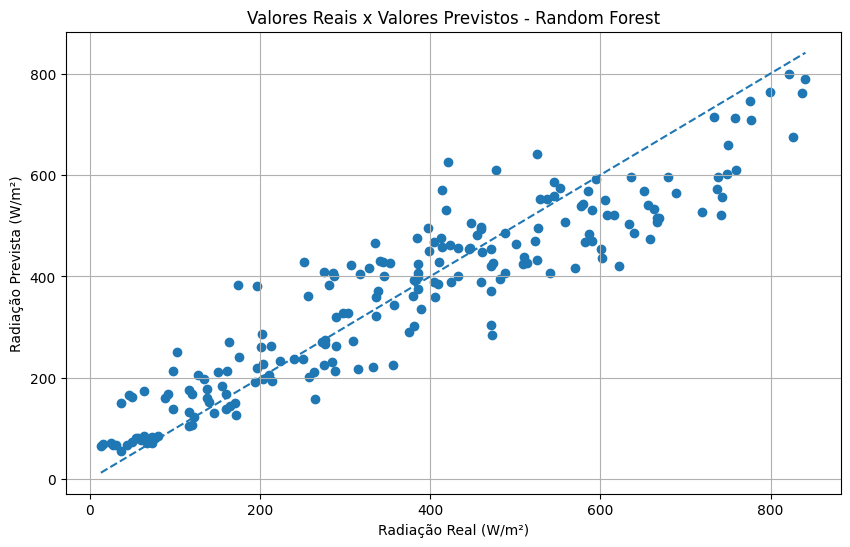

In [17]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_teste,
    previsao_floresta
)

plt.plot(
    [y_teste.min(), y_teste.max()],
    [y_teste.min(), y_teste.max()],
    "--"
)

plt.xlabel("Radiação Real (W/m²)")
plt.ylabel("Radiação Prevista (W/m²)")
plt.title("Valores Reais x Valores Previstos - Random Forest")

plt.grid(True)

plt.show()

## Interpretação dos resultados

Os três modelos foram treinados utilizando exatamente a mesma divisão de tempo dos dados, com os primeiros 80% dos registros para treino e os últimos 20% para teste.

A Regressão Linear apresentou o menor desempenho, indicando que a relação entre as variáveis meteorológicas e a radiação solar não é totalmente linear.

A Árvore de Decisão conseguiu capturar relações não lineares e apresentou melhoria nas métricas MAE, MSE e R².

O Random Forest apresentou o melhor desempenho entre os modelos avaliados, obtendo menor erro e maior capacidade de explicação da variabilidade dos dados.

A variável hora possui grande influência na previsão da radiação solar, pois está diretamente relacionada à posição do Sol ao longo do dia. Além disso, cobertura de nuvens, temperatura e umidade também afetam a quantidade de radiação recebida.

É importante destacar que prever radiação solar não equivale a prever geração elétrica. A produção de energia depende também de fatores como eficiência dos painéis, orientação do sistema fotovoltaico, perdas elétricas, manutenção e condições operacionais.